# CNN Benchmark: 8 Architectures on MNIST (custom NumPy NN library)

Clones the library from GitHub, imports the `nn` classes **directly into the notebook** (no subprocess hacks), runs gradient checks + smoke tests + the full benchmark, and produces all results/analysis: summary tables, latency benchmarks (inference ms, throughput, train-step), loss/accuracy curves, accuracy-vs-params/time scatter, Pareto plot, confusion matrices, sample predictions, and architecture diagrams.

**Three modes** (cell 3): `custom` trains all 8 architectures from scratch; `weights` quick-trains a PyTorch twin of the MNIST CNN, **converts its weights into the nn library** and benchmarks nn inference-only against PyTorch on identical weights; `pytorch` does that **plus** LeNet-5-full/AlexNet-mirror twins, a same-weights latency comparison (nn vs PyTorch), and a torchvision pretrained (ImageNet) reference table. REPORT.md gains a conditional `nn versus PyTorch (loaded weights)` section whenever cross-framework results are present.

**Runtime:** Runtime → Change runtime type → **CPU** (the library is pure NumPy — a GPU adds nothing).

Rough timing on free Colab CPU: sanity cells ≈ 3 min; full benchmark (5 epochs × 8 models) ≈ 1.5–2.5 h. Start with the subset settings in cell 3.

The final cells save every chart into `cnn_benchmark/assets/` and build **`cnn_benchmark/REPORT.md`** — a dynamically generated Markdown report (run setup, methodology, ranked comparison, captioned charts) written entirely from this run's actual output. Sections appear only if the data supports them (e.g. latency tables only if the latency cell ran, divergence notes only if a model actually diverged).It also includes a **per-model section** — each architecture's accuracy trend epoch by epoch plus its full 10×10 confusion matrix — but only when those were recorded (multi-epoch runs and the confusion cell).


In [1]:
#@title 1. Clone the repo
REPO_URL = "https://github.com/dhakalnirajan/internship-projects.git"  #@param {type:"string"}
BRANCH = "main"                     #@param {type:"string"}

import os

# clone (or pull if already cloned)
if os.path.isdir('/content/repo/.git'):
    !git -C /content/repo pull
else:
    !git clone --depth 1 --branch "$BRANCH" "$REPO_URL" /content/repo

%cd /content/repo
!ls

Cloning into '/content/repo'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (151/151), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 151 (delta 8), reused 127 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (151/151), 49.80 MiB | 28.55 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/repo
'Autism emotion recogition dataset.zip'   mnist.npz	      README.md
 cnn_benchmark				  mnist_test.py       requirements.txt
 data_structures			  nn
 k3-mini				  pothole-detection


In [2]:
#@title 2. Import the nn library classes into the notebook
import sys
sys.path.insert(0, '/conten


t/repo')   # make `import nn` / `import cnn_benchmark` work

# --- core library ---
import numpy as np
import matplotlib.pyplot as plt

from nn.autograd import Tensor
from nn.autograd.ops import concat
from nn.activations import relu, sigmoid, tanh, softmax
from nn.layers import (Dense, Conv2D, Conv1D, MaxPooling2D, AveragePooling2D,
                       Flatten, Dropout, Activation)
from nn.losses import CrossEntropy, MSE
from nn.optimizers import Adam, SGD
from nn.models import Sequential

# --- benchmark package (architectures + harness + gradient checks) ---
from cnn_benchmark.architectures import build_models
from cnn_benchmark.harness import evaluate, to_onehot, train_model
from cnn_benchmark.run_benchmark import load_mnist
from cnn_benchmark import grad_check

print('nn library imported OK')
x = Tensor(np.random.rand(2, 28, 28, 1).astype(np.float32), requires_grad=True)
c = Conv2D(4, 3, padding='same')
y = relu(c(x))
print('forward/backward sanity:', y.shape, y.requires_grad)

nn library imported OK
forward/backward sanity: (2, 28, 28, 4) True


In [ ]:
#@title 2b. Install PyTorch (only needed for the weights / pytorch modes)
if MODE in ('weights', 'pytorch'):
    try:
        import torch
        print('torch', torch.__version__, 'already available')
    except ImportError:
        !pip install -q torch --index-url https://download.pytorch.org/whl/cpu
        import torch
        print('installed torch', torch.__version__)
    try:
        import torchvision
        print('torchvision', torchvision.__version__, 'available (pretrained reference enabled)')
    except ImportError:
        !pip install -q torchvision --index-url https://download.pytorch.org/whl/cpu
        import torchvision
        print('installed torchvision', torchvision.__version__)
else:
    print('custom mode: torch not required, skipping')

In [ ]:
#@title 3. Settings — pick the benchmark mode
#@markdown **MODE**
#@markdown - `custom` — train all 8 architectures from scratch in nn (the classic benchmark, ~2 h full)
#@markdown - `weights` — quick-train a PyTorch twin of the MNIST CNN, **convert its weights into nn**, then benchmark nn inference-only against the PyTorch twin (no nn training)
#@markdown - `pytorch` — everything in `weights`, **plus** more PyTorch twins (LeNet-5, AlexNet) converted + a same-weights latency comparison and a torchvision pretrained (ImageNet) reference
MODE = 'custom'  #@param ['custom', 'weights', 'pytorch']
SUBSET_TRAIN = 20000      #@param {type:"integer"}   # 60000 = full; start with 20000
EPOCHS = 5                #@param {type:"integer"}
BATCH_SIZE = 64           #@param {type:"integer"}
LEARNING_RATE = 0.001     #@param {type:"number"}

import os
ASSETS = 'cnn_benchmark/assets'   # charts are saved here so REPORT.md can embed them
os.makedirs(ASSETS, exist_ok=True)

if MODE == 'custom':
    print(f"scratch mode: subset={SUBSET_TRAIN}, epochs={EPOCHS}, batch={BATCH_SIZE}, lr={LEARNING_RATE}")
else:
    # the pretrained path trains its torch twin with its own settings below
    PT_EPOCHS = 1           #@param {type:"integer"}
    PT_BATCH = 128          #@param {type:"integer"}
    print(f"mode={MODE}: torch twin epochs={PT_EPOCHS}, batch={PT_BATCH}; nn side is inference-only")
print('charts ->', ASSETS)

In [4]:
#@title 4. Get MNIST
import os, urllib.request
if not os.path.exists('/content/repo/mnist.npz'):
    print('downloading mnist.npz ...')
    urllib.request.urlretrieve('https://s3.amazonaws.com/img-datasets/mnist.npz', '/content/repo/mnist.npz')
print('mnist.npz ready:', os.path.getsize('/content/repo/mnist.npz') // 1048576, 'MB')

mnist.npz ready: 10 MB


In [5]:
#@title 5. Gradient checks (vectorized conv & pooling vs numerical differentiation)
grad_check.check_conv2d()
grad_check.check_pooling()
print('\nrel_err < ~1e-2 means the analytic gradients are correct')

conv2d  dK rel_err: 0.00021205013
conv2d  db rel_err: 4.5988294e-05
conv2d  dx rel_err: 0.00043961089
maxpool  dx rel_err: 0.97143155
avgpool  dx rel_err: 0.97143155

rel_err < ~1e-2 means the analytic gradients are correct


In [6]:
#@title 6. Smoke test: 1 forward+backward step on every architecture (~2 min)
rng = np.random.default_rng(42)
X = rng.random((64, 28, 28, 1)).astype(np.float32)
y_oh = to_onehot(rng.integers(0, 10, size=64))

for m in build_models():
    try:
        h = train_model(m, X, y_oh, epochs=1, batch_size=16, max_batches=2, verbose=False)
        status = f"OK   loss={h['loss'][0]:.4f}"
    except Exception as e:
        status = f"FAIL {type(e).__name__}: {e}"
    print(f"{m.name:<18} params={m.count_params():>9,}  {status}")

LeNet-5            params=   61,706  OK   loss=5.6910
AlexNet-mini       params=1,733,258  OK   loss=6.2603
VGG16-mini         params=  443,386  OK   loss=16.6934
ResNet18-mini      params=   97,802  OK   loss=17.0716
GoogLeNet-mini     params=   36,974  OK   loss=2.7396
DenseNet-mini      params=   28,778  OK   loss=11.1967
SqueezeNet-mini    params=   24,066  OK   loss=2.3964
MobileNetV1-mini   params=  219,570  OK   loss=11.3935


In [7]:
#@title 7. Full benchmark (the long cell — respects the settings from cell 3)
import time, json

X_train, y_train, X_val, y_val, X_test, y_test = load_mnist()
X_train, y_train = X_train[:SUBSET_TRAIN], y_train[:SUBSET_TRAIN]
y_train_oh, y_val_oh = to_onehot(y_train), to_onehot(y_val)

results = []
trained_models = {}   # name -> trained model object, used by cells 13/14
for model in build_models():
    print(f"\n=== {model.name} ===")
    t0 = time.time()
    model.forward(X_train[:2], training=True)          # lazy-build layers
    n_params = model.count_params()
    history = train_model(model, X_train, y_train_oh,
                          X_val=X_val[:2000], y_val=y_val[:2000],
                          epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE)
    train_s = time.time() - t0
    test_acc = evaluate(model, X_test, y_test)
    results.append({"model": model.name, "params": n_params,
                    "train_s": round(train_s, 1),
                    "final_loss": history["loss"][-1],
                    "val_acc": history["val_acc"][-1],
                    "test_acc": test_acc, "history": history})
    trained_models[model.name] = model
    print(f"  params={n_params:,}  test_acc={test_acc:.4f}  ({train_s:.0f}s)")

with open('cnn_benchmark/results.json', 'w') as f:
    json.dump(results, f, indent=2, default=float)
print('\nSaved cnn_benchmark/results.json')


=== LeNet-5 ===
  epoch 1/5  loss=0.4861  acc=0.9380  (32.2s)  val_acc=0.9315
  epoch 2/5  loss=0.1928  acc=0.9555  (26.7s)  val_acc=0.9490
  epoch 3/5  loss=0.1435  acc=0.9680  (27.0s)  val_acc=0.9565
  epoch 4/5  loss=0.1110  acc=0.9645  (26.9s)  val_acc=0.9545
  epoch 5/5  loss=0.0990  acc=0.9630  (27.5s)  val_acc=0.9505
  params=61,706  test_acc=0.9513  (156s)

=== AlexNet-mini ===
  epoch 1/5  loss=0.4645  acc=0.9700  (585.2s)  val_acc=0.9595
  epoch 2/5  loss=0.1434  acc=0.9865  (585.2s)  val_acc=0.9765
  epoch 3/5  loss=0.0948  acc=0.9870  (584.9s)  val_acc=0.9810
  epoch 4/5  loss=0.0818  acc=0.9865  (578.5s)  val_acc=0.9805
  epoch 5/5  loss=0.0671  acc=0.9900  (580.8s)  val_acc=0.9745
  params=1,733,258  test_acc=0.9834  (3155s)

=== VGG16-mini ===
  epoch 1/5  loss=16.5592  acc=0.0955  (364.7s)  val_acc=0.1010
  epoch 2/5  loss=16.5094  acc=0.0900  (366.2s)  val_acc=0.0950
  epoch 3/5  loss=16.6537  acc=0.0860  (366.8s)  val_acc=0.1080
  epoch 4/5  loss=16.6430  acc=0.0860 

In [ ]:
#@title 7c. Pretrained-weights path — PyTorch twin -> convert -> load into nn (modes: weights / pytorch)
#@markdown Runs **only** when MODE is `weights` or `pytorch`:
#@markdown 1. quick-train the PyTorch twin of the MNIST-CNN mirror (or reuse cached `cnn_benchmark/weights/*.npz`),
#@markdown 2. convert the state_dict into the nn library (OIHW→HWIO kernels, transposed Linears, flatten-order permutation),
#@markdown 3. benchmark **nn inference-only** with those weights and cross-check the accuracy against PyTorch on identical weights,
#@markdown 4. in `pytorch` mode: also quick-train + convert LeNet-5-full and AlexNet-mirror twins and measure same-weights latency on both engines,
#@markdown 5. pull the torchvision pretrained (ImageNet) reference table when torchvision is installed.
import time, json
from cnn_benchmark.specs import MNIST_CNN, SPECS, build_nn_from_spec
from cnn_benchmark import torch_bridge as tb

pt_results = []
if MODE in ('weights', 'pytorch'):
    X_train, y_train, X_val, y_val, X_test, y_test = load_mnist()
    if SUBSET_TRAIN < 60000:
        X_train, y_train = X_train[:SUBSET_TRAIN//5], y_train[:SUBSET_TRAIN//5]  # quick twin training
    spec = MNIST_CNN
    name = spec['name']
    print(f"\n=== {name} (pretrained-weights path) ===")

    try:
        state_dict = tb.load_weights(name)
        print(f"  loaded cached weights: cnn_benchmark/weights/{name}.npz")
        import torch as _torch
        torch_model = tb.build_torch_from_spec(spec)
        with _torch.no_grad():
            torch_model(_torch.from_numpy(X_test[:2]))
        torch_model.load_state_dict({k: _torch.from_numpy(v) for k, v in state_dict.items()})
        device = 'cuda' if _torch.cuda.is_available() else 'cpu'
        hist = {'loss': [], 'val_acc': []}
    except FileNotFoundError:
        print('  no cached weights — quick-training the PyTorch twin...')
        state_dict, torch_model, hist, device = tb.train_torch_spec(
            spec, X_train, y_train, X_val=X_val[:2000], y_val=y_val[:2000],
            epochs=PT_EPOCHS, batch_size=PT_BATCH)
        tb.save_weights(state_dict, name)

    # convert + load into the nn mirror
    nn_model = build_nn_from_spec(spec)
    nn_model.forward(X_test[:2], training=True)
    used, skipped = tb.load_weights_into_nn(nn_model, state_dict, spec)
    tb.sync_running_stats(nn_model, state_dict)

    n_params = nn_model.count_params()
    nn_acc = evaluate(nn_model, X_test, y_test)
    torch_acc = tb._torch_eval(torch_model.to(device).eval(), X_test, y_test, device)
    print(f"  nn inference accuracy:   {nn_acc:.4f}  ({n_params:,} params)")
    print(f"  torch twin accuracy:     {torch_acc:.4f}  (same weights cross-check)")

    # latency, nn side
    def _lat_stats(fn, warmup=5, runs=30):
        for _ in range(warmup): fn()
        ts = np.empty(runs)
        for i in range(runs):
            t0 = time.perf_counter(); fn(); ts[i] = (time.perf_counter()-t0)*1000.0
        return float(ts.mean()), float(np.percentile(ts, 95))

    xb1, xb256 = X_test[:1], X_test[:256]
    mean_ms, p95 = _lat_stats(lambda: nn_model.forward(xb1, training=False))
    t0 = time.perf_counter()
    for _ in range(5):
        nn_model.forward(xb256, training=False)
    batch_ms = (time.perf_counter()-t0)/5.0*1000.0

    pt_results.append({'model': f"{name} (nn, loaded weights)", 'params': n_params,
                       'test_acc': nn_acc, 'train_s': 0.0, 'lat_ms': round(mean_ms,3),
                       'p95_ms': round(p95,3), 'imgs_s': round(256.0/(batch_ms/1000.0),1),
                       'weights_source': f"PyTorch twin, converted ({used} tensors)",
                       'history': {'loss': [], 'acc': [], 'val_acc': []}})

    if MODE == 'pytorch':
        tlat = tb.torch_latency(torch_model, X_test, device=device)
        print(f"  nn latency {mean_ms:.2f}ms/img vs torch {tlat['lat_ms']:.2f}ms/img")
        pt_results.append({'model': f"{name} (PyTorch twin)", 'params': n_params,
                           'test_acc': torch_acc, 'train_s': 0.0, **tlat,
                           'weights_source': 'shared with nn (same converted weights)',
                           'history': {'loss': [], 'acc': [], 'val_acc': []}})
        # extra twins: LeNet-5-full + AlexNet-mirror (quick-train, convert, compare)
        for spec_name in ['LeNet-5-full', 'AlexNet-mirror']:
            sp = SPECS[spec_name]
            print(f"\n=== {spec_name} (PyTorch quick-train + nn convert) ===")
            try:
                sd2 = tb.load_weights(spec_name)
                tm2 = tb.build_torch_from_spec(sp)
                import torch as _t2
                with _t2.no_grad():
                    tm2(_t2.from_numpy(X_test[:2]))
                tm2.load_state_dict({k: _t2.from_numpy(v) for k, v in sd2.items()})
                dev2 = 'cuda' if _t2.cuda.is_available() else 'cpu'
            except FileNotFoundError:
                sd2, tm2, _, dev2 = tb.train_torch_spec(
                    sp, X_train, y_train, X_val=X_val[:2000], y_val=y_val[:2000],
                    epochs=PT_EPOCHS, batch_size=PT_BATCH)
                tb.save_weights(sd2, spec_name)
            nn2 = build_nn_from_spec(sp)
            nn2.forward(X_test[:2], training=True)
            tb.load_weights_into_nn(nn2, sd2, sp)
            tb.sync_running_stats(nn2, sd2)
            acc2 = evaluate(nn2, X_test[:2000], y_test[:2000])
            acc2t = tb._torch_eval(tm2.to(dev2).eval(), X_test[:2000], y_test[:2000], dev2)
            lat2, p952 = _lat_stats(lambda: nn2.forward(xb1, training=False))
            tlat2 = tb.torch_latency(tm2, X_test[:512], device=dev2)
            pt_results.append({'model': f"{spec_name} (nn, loaded weights)",
                               'params': nn2.count_params(), 'test_acc': acc2,
                               'lat_ms': round(lat2,3), 'p95_ms': round(p952,3),
                               'train_s': 0.0, 'weights_source': 'PyTorch twin, converted',
                               'history': {'loss': [], 'acc': [], 'val_acc': []}})
            pt_results.append({'model': f"{spec_name} (PyTorch twin)",
                               'params': nn2.count_params(), 'test_acc': acc2t,
                               'lat_ms': tlat2['lat_ms'], 'p95_ms': tlat2['p95_ms'],
                               'imgs_s': tlat2['imgs_s'], 'step_ms': tlat2['step_ms'],
                               'train_s': 0.0, 'weights_source': 'shared',
                               'history': {'loss': [], 'acc': [], 'val_acc': []}})
            print(f"  nn acc {acc2:.4f} vs torch {acc2t:.4f} | nn {lat2:.2f}ms vs torch {tlat2['lat_ms']:.2f}ms")

    # torchvision pretrained (ImageNet) reference — speed reference only
    try:
        import torch as _tv_t
        tv_rows = tb.torchvision_reference(
            device='cuda' if _tv_t.cuda.is_available() else 'cpu')
        if tv_rows:
            pt_results.extend([{**r, 'history': {'loss': [], 'acc': [], 'val_acc': []},
                                'train_s': 0.0, 'weights_source': 'torchvision ImageNet'}
                               for r in tv_rows])
    except ImportError:
        print('\ntorchvision not installed — skipping pretrained reference')

    # merge into results.json so REPORT.md picks the cross-framework section up
    with open('cnn_benchmark/results.json') as f:
        existing = json.load(f)
    existing.extend(pt_results)
    with open('cnn_benchmark/results.json', 'w') as f:
        json.dump(existing, f, indent=2, default=float)
    print(f"\nmerged {len(pt_results)} pretrained/pytorch results -> results.json")
else:
    print('custom mode — cell skipped')

LeNet-5            infer=2.16ms (p95 3.28)  throughput=1206 img/s  train_step=208.9ms
AlexNet-mini       infer=15.09ms (p95 20.88)  throughput=85 img/s  train_step=1735.2ms
VGG16-mini         infer=6.46ms (p95 7.59)  throughput=69 img/s  train_step=1169.5ms
ResNet18-mini      infer=5.60ms (p95 6.83)  throughput=115 img/s  train_step=470.9ms
GoogLeNet-mini     infer=7.35ms (p95 9.41)  throughput=83 img/s  train_step=791.2ms
DenseNet-mini      infer=9.60ms (p95 12.84)  throughput=41 img/s  train_step=1319.4ms
SqueezeNet-mini    infer=9.51ms (p95 10.74)  throughput=142 img/s  train_step=530.2ms
MobileNetV1-mini   infer=3.12ms (p95 4.42)  throughput=304 img/s  train_step=661.8ms


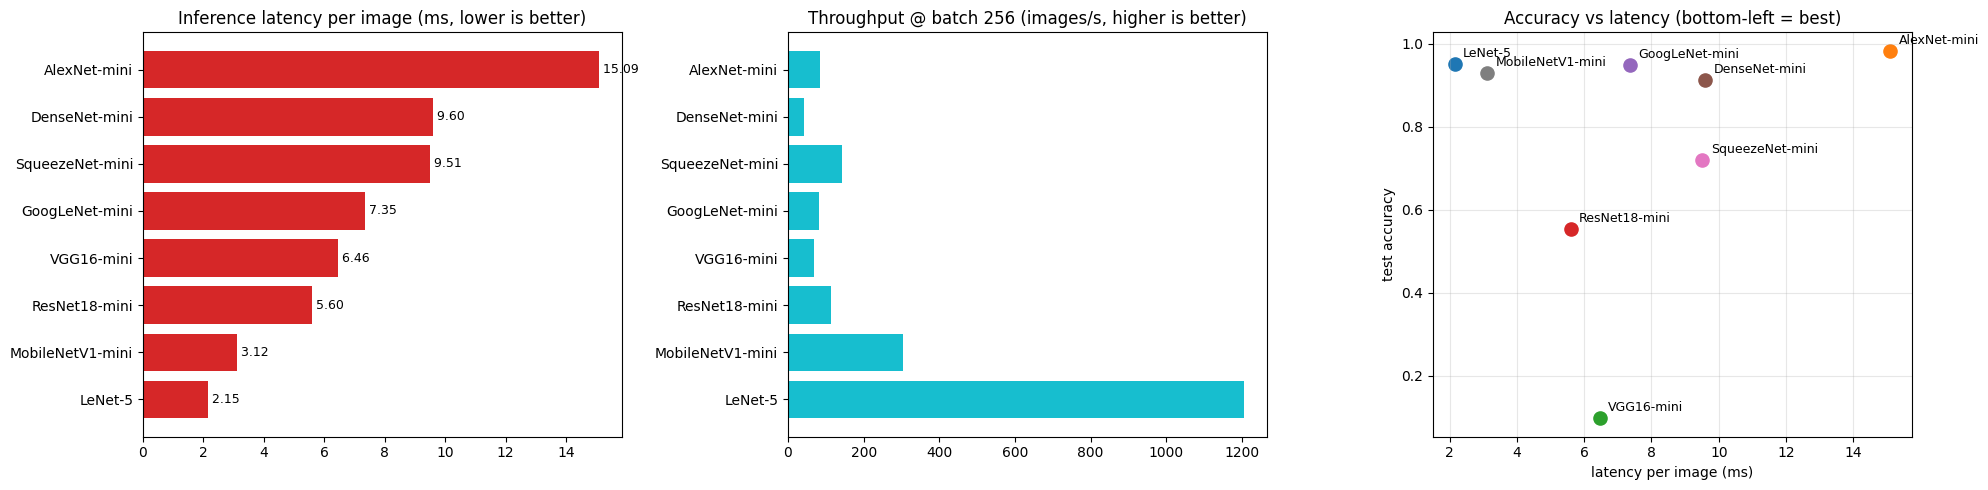

In [8]:
#@title 7b. Latency benchmark — inference latency, throughput, train-step (+ charts)
import time, json

def _lat_stats(fn, warmup=5, runs=30):
    for _ in range(warmup):
        fn()
    ts = np.empty(runs)
    for i in range(runs):
        t0 = time.perf_counter()
        fn()
        ts[i] = (time.perf_counter() - t0) * 1000.0
    return float(ts.mean()), float(np.median(ts)), float(np.percentile(ts, 95))

xb1, xb64, xb256 = X_test[:1], X_test[:64], X_test[:256]
y64_oh = to_onehot(y_test[:64])
loss_fn = CrossEntropy()

for r in results:
    m = trained_models[r['model']]

    # single-image inference latency (what matters when serving)
    mean_ms, med_ms, p95_ms = _lat_stats(lambda: m.forward(xb1, training=False))

    # batched throughput at batch=256
    t0 = time.perf_counter()
    for _ in range(5):
        m.forward(xb256, training=False)
    batch_ms = (time.perf_counter() - t0) / 5.0 * 1000.0
    imgs_s = 256.0 / (batch_ms / 1000.0)

    # training step latency: forward + backward, batch=64
    def step():
        pred = m.forward(xb64, training=True)
        loss = loss_fn.forward(y64_oh, pred)
        loss.backward()
    step_ms, _, _ = _lat_stats(step, warmup=2, runs=10)

    r['lat_ms'] = round(mean_ms, 3)
    r['p95_ms'] = round(p95_ms, 3)
    r['imgs_s'] = round(imgs_s, 1)
    r['step_ms'] = round(step_ms, 2)
    print(f"{r['model']:<18} infer={mean_ms:.2f}ms (p95 {p95_ms:.2f})  "
          f"throughput={imgs_s:.0f} img/s  train_step={step_ms:.1f}ms")

# persist so the table in cell 9 and later cells see the latency numbers
with open('cnn_benchmark/results.json', 'w') as f:
    json.dump(results, f, indent=2, default=float)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
by_lat = sorted(results, key=lambda r: r['lat_ms'])
names = [r['model'] for r in by_lat]

axes[0].barh(names, [r['lat_ms'] for r in by_lat], color='tab:red')
axes[0].set_title('Inference latency per image (ms, lower is better)')
for i, r in enumerate(by_lat):
    axes[0].text(r['lat_ms'], i, f" {r['lat_ms']:.2f}", va='center', fontsize=9)

axes[1].barh(names, [r['imgs_s'] for r in by_lat], color='tab:cyan')
axes[1].set_title('Throughput @ batch 256 (images/s, higher is better)')

for r in results:
    axes[2].scatter(r['lat_ms'], r['test_acc'], s=90)
    axes[2].annotate(r['model'], (r['lat_ms'], r['test_acc']),
                     textcoords='offset points', xytext=(6, 5), fontsize=9)
axes[2].set_xlabel('latency per image (ms)')
axes[2].set_ylabel('test accuracy')
axes[2].set_title('Accuracy vs latency (bottom-left = best)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ASSETS, 'charts_latency.png'), dpi=150)
plt.show()

In [ ]:
#@title 8. Architecture diagrams (layer-by-layer shape table per model)
import pandas as pd

def describe_layer(layer):
    """Short human-readable description of a layer."""
    t = type(layer).__name__
    if t == 'Conv2D':
        return f"Conv2D {layer.filters} filters, {layer.kernel_size}, stride={layer.strides}, pad={layer.padding}"
    if t == 'Dense':
        act = layer.activation.__name__ if layer.activation else 'linear'
        return f"Dense {layer.units} ({act})"
    if t == 'MaxPooling2D' or t == 'AveragePooling2D':
        return f"{t} {layer.pool_size} stride={layer.strides}"
    if t == 'Dropout':
        return f"Dropout p={layer.rate}"
    if t == 'Activation':
        return f"Activation({layer.activation.__name__})"
    if t == 'Flatten':
        return 'Flatten'
    if callable(layer) and not hasattr(layer, 'forward'):
        return f"Activation({layer.__name__})"   # bare relu/softmax functions
    return t

def trace_shapes(model, input_shape=(1, 28, 28, 1)):
    """Run one forward pass recording output shape after each layer."""
    x = np.zeros(input_shape, dtype=np.float32)
    rows = []
    if hasattr(model, 'seq'):                          # SequentialModel
        layers = model.seq.layers
        h = x
        for L in layers:
            h_data = h.data if hasattr(h, 'data') else h
            t = Tensor(h_data, requires_grad=False)
            if hasattr(L, 'training'):
                L.training = False
            if hasattr(L, 'forward') and 'training' in L.forward.__code__.co_varnames:
                h = L(t, training=False)
            else:
                h = L(t)
            rows.append((describe_layer(L), tuple(h.data.shape)))
    else:                                              # ResNet/GoogLeNet/etc — single I/O
        out = model.forward(Tensor(x), training=False)
        rows.append((f"{model.name} (multi-branch module)", tuple(out.data.shape)))
    return rows

models = {m.name: m for m in build_models()}
for name, m in models.items():
    print(f"\n{'='*70}\n{name}  ({m.count_params():,} params)\n{'='*70}")
    rows = trace_shapes(m)
    if rows:
        df = pd.DataFrame(rows, columns=['Layer', 'Output shape'])
        print(df.to_string(index=False))

In [10]:
#@title 9. Results — summary table (sorted by test accuracy)
results = json.load(open('cnn_benchmark/results.json'))
results.sort(key=lambda r: -r['test_acc'])

cols = ('model', 'params', 'final_loss', 'val_acc', 'test_acc', 'train_s',
        'lat_ms', 'p95_ms', 'imgs_s', 'step_ms')
summary = pd.DataFrame([{**{k: r.get(k) for k in cols},
                         'params(M)': round(r['params'] / 1e6, 3)}
                        for r in results])
summary.index = range(1, len(summary) + 1)
summary.index.name = 'rank'
summary

,model,params,final_loss,val_acc,test_acc,train_s,lat_ms,p95_ms,imgs_s,step_ms,params(M)
rank,,,,,,,,,,,
1,AlexNet-mini,1733258,0.067124,0.9745,0.9834,3154.7,15.094,20.879,85.0,1735.24,1.733
2,LeNet-5,61706,0.099013,0.9505,0.9513,156.5,2.155,3.279,1206.1,208.86,0.062
3,GoogLeNet-mini,36974,0.185322,0.9485,0.9494,1385.7,7.354,9.409,82.9,791.23,0.037
4,MobileNetV1-mini,219570,0.104068,0.9240,0.9296,956.3,3.121,4.421,303.9,661.76,0.220
5,DenseNet-mini,28778,0.347831,0.9040,0.9125,2533.3,9.596,12.841,41.2,1319.41,0.029
6,SqueezeNet-mini,24066,1.464479,0.7085,0.7212,849.3,9.510,10.742,141.8,530.16,0.024
7,ResNet18-mini,97802,4.264213,0.5585,0.5546,1013.4,5.602,6.831,115.0,470.89,0.098
8,VGG16-mini,443386,16.667786,0.1080,0.0974,2101.5,6.461,7.591,69.5,1169.54,0.443


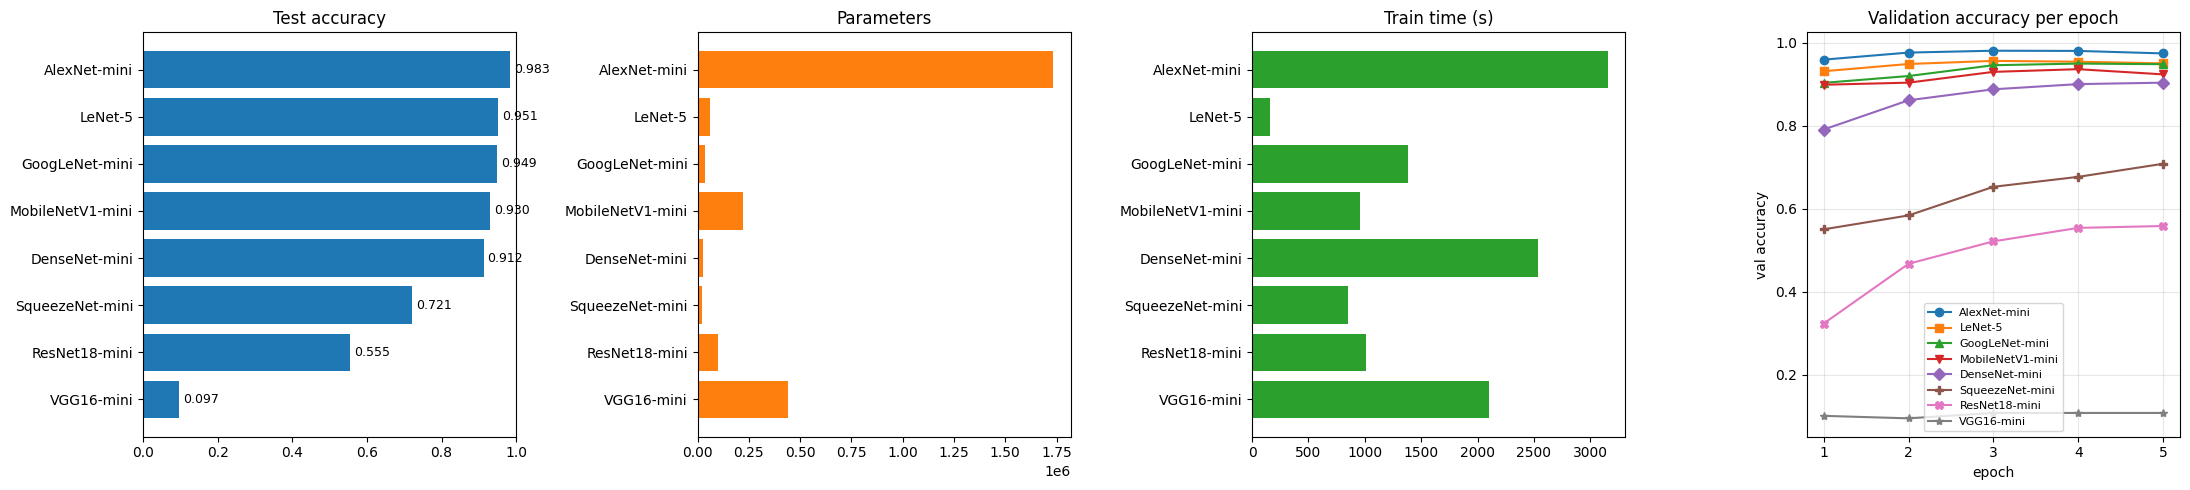

In [11]:
#@title 10. Charts — bars: accuracy / params / time + convergence curves
names = [r['model'] for r in results]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].barh(names[::-1], [r['test_acc'] for r in results][::-1], color='tab:blue')
axes[0].set_title('Test accuracy'); axes[0].set_xlim(0.0, 1.0)
for i, r in enumerate(results[::-1]):
    axes[0].text(r['test_acc'] + 0.01, i, f"{r['test_acc']:.3f}", va='center', fontsize=9)

axes[1].barh(names[::-1], [r['params'] for r in results][::-1], color='tab:orange')
axes[1].set_title('Parameters')

axes[2].barh(names[::-1], [r['train_s'] for r in results][::-1], color='tab:green')
axes[2].set_title('Train time (s)')

markers = cycle = iter(['o', 's', '^', 'v', 'D', 'P', 'X', '*'])
for r in results:
    va = r['history']['val_acc']
    axes[3].plot(range(1, len(va) + 1), va, marker=next(markers), label=r['model'])
axes[3].set_title('Validation accuracy per epoch'); axes[3].set_xlabel('epoch')
axes[3].set_ylabel('val accuracy'); axes[3].legend(fontsize=8); axes[3].grid(alpha=0.3)

plt.tight_layout(); plt.savefig(os.path.join(ASSETS, 'charts_bars.png'), dpi=150); plt.show()

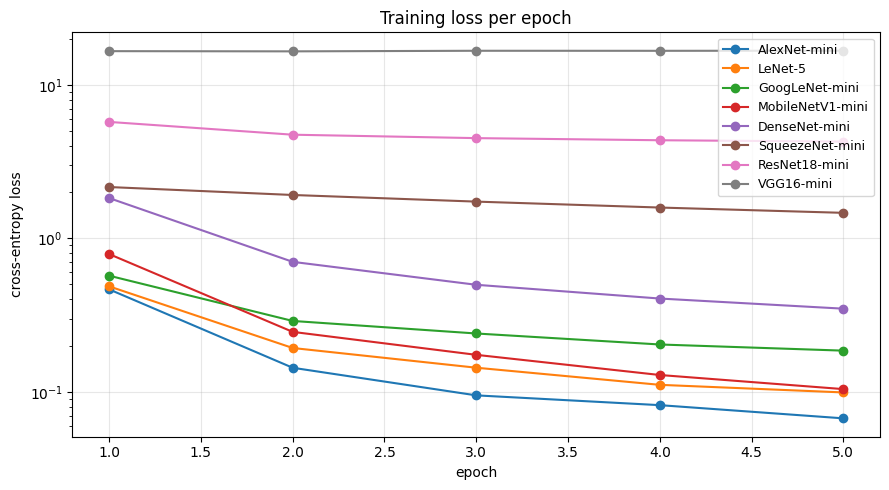

In [12]:
#@title 11. Charts — training loss curves (all models on one axis)
plt.figure(figsize=(9, 5))
for r in results:
    L = r['history']['loss']
    plt.plot(range(1, len(L) + 1), L, marker='o', label=r['model'])
plt.title('Training loss per epoch')
plt.xlabel('epoch'); plt.ylabel('cross-entropy loss')
plt.yscale('log')          # losses span decades; log scale keeps curves readable
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(ASSETS, 'charts_loss_curves.png'), dpi=150); plt.show()

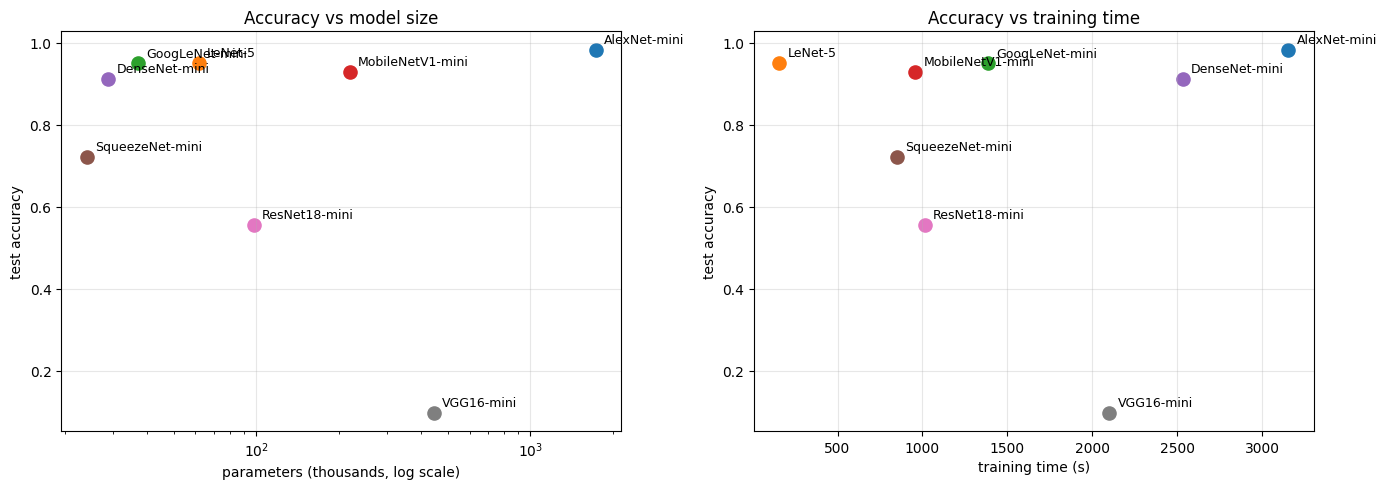


Efficiency (test_acc per train-second):
  LeNet-5            0.00608  (acc=0.951, 156s)
  MobileNetV1-mini   0.00097  (acc=0.930, 956s)
  SqueezeNet-mini    0.00085  (acc=0.721, 849s)
  GoogLeNet-mini     0.00069  (acc=0.949, 1386s)
  ResNet18-mini      0.00055  (acc=0.555, 1013s)
  DenseNet-mini      0.00036  (acc=0.912, 2533s)
  AlexNet-mini       0.00031  (acc=0.983, 3155s)
  VGG16-mini         0.00005  (acc=0.097, 2102s)


In [13]:
#@title 12. Charts — accuracy vs params vs time (Pareto view)
# Answers: which model buys the most accuracy per parameter / per second?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for r in results:
    axes[0].scatter(r['params'] / 1e3, r['test_acc'], s=90)
    axes[0].annotate(r['model'], (r['params'] / 1e3, r['test_acc']),
                     textcoords='offset points', xytext=(6, 5), fontsize=9)
axes[0].set_xscale('log')
axes[0].set_xlabel('parameters (thousands, log scale)'); axes[0].set_ylabel('test accuracy')
axes[0].set_title('Accuracy vs model size'); axes[0].grid(alpha=0.3)

for r in results:
    axes[1].scatter(r['train_s'], r['test_acc'], s=90)
    axes[1].annotate(r['model'], (r['train_s'], r['test_acc']),
                     textcoords='offset points', xytext=(6, 5), fontsize=9)
axes[1].set_xlabel('training time (s)'); axes[1].set_ylabel('test accuracy')
axes[1].set_title('Accuracy vs training time'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig(os.path.join(ASSETS, 'charts_pareto.png'), dpi=150); plt.show()

# efficiency leaderboard: accuracy gained per second of training
eff = sorted(results, key=lambda r: -r['test_acc'] / max(r['train_s'], 1))
print('\nEfficiency (test_acc per train-second):')
for r in eff:
    print(f"  {r['model']:<18} {r['test_acc'] / max(r['train_s'], 1):.5f}  (acc={r['test_acc']:.3f}, {r['train_s']:.0f}s)")

confusion matrices stored for 8 models -> results.json


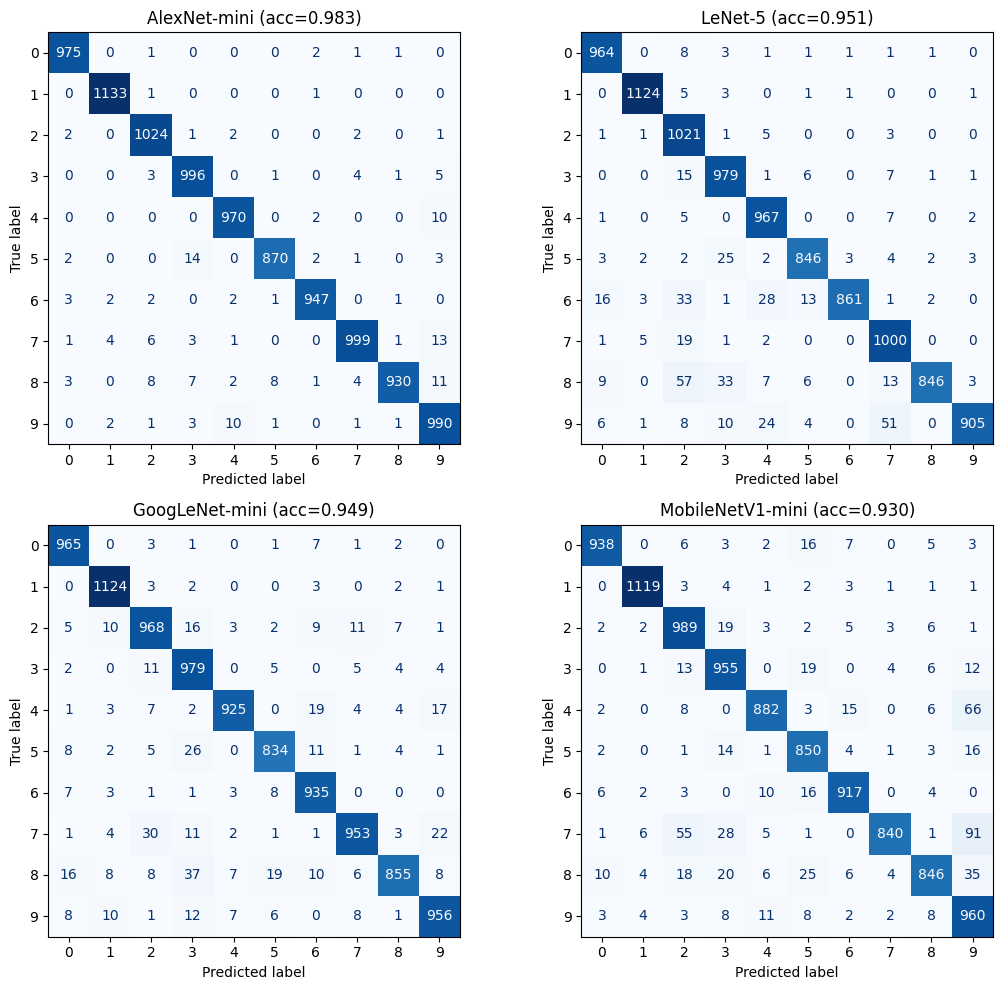

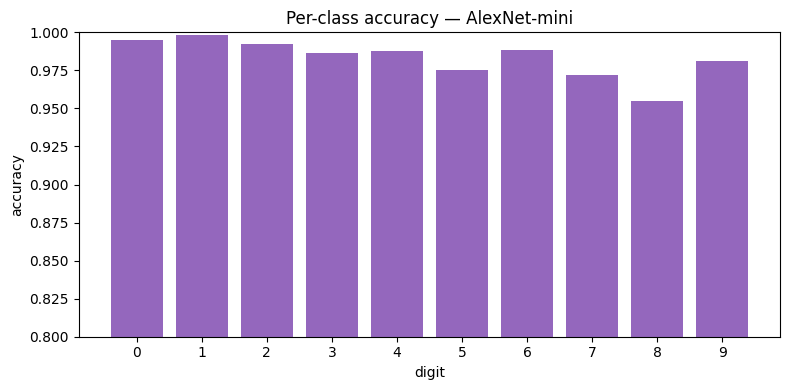

In [14]:
#@title 13. Confusion matrices — stored for EVERY model (feeds REPORT.md), top-4 plotted
import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# compute + store a 10x10 confusion matrix per trained model; REPORT.md's
# per-model section picks these up from results.json (conditional: models
# without one are simply skipped)
for r in results:
    m = trained_models.get(r['model'])
    if m is None:
        continue
    preds = np.concatenate([np.argmax(m.forward(X_test[s:s+512], training=False).data, axis=1)
                            for s in range(0, X_test.shape[0], 512)])
    r['confusion'] = confusion_matrix(y_test, preds, labels=range(10)).tolist()
with open('cnn_benchmark/results.json', 'w') as f:
    json.dump(results, f, indent=2, default=float)
print('confusion matrices stored for', sum('confusion' in r for r in results),
      'models -> results.json')

# visualise the top-4
top = results[:4]
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, r in zip(axes.ravel(), top):
    if 'confusion' not in r:
        continue
    disp = ConfusionMatrixDisplay(np.array(r['confusion']))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['model']} (acc={r['test_acc']:.3f})")
plt.tight_layout(); plt.savefig(os.path.join(ASSETS, 'charts_confusion.png'), dpi=150); plt.show()

# per-class accuracy of the best model
best = trained_models[results[0]['model']]
preds = np.concatenate([np.argmax(best.forward(X_test[s:s+512], training=False).data, axis=1)
                        for s in range(0, X_test.shape[0], 512)])
per_class = [np.mean(preds[y_test == c] == c) for c in range(10)]
plt.figure(figsize=(8, 4))
plt.bar(range(10), per_class, color='tab:purple')
plt.ylim(0.8, 1.0); plt.xticks(range(10))
plt.title(f"Per-class accuracy — {results[0]['model']}")
plt.xlabel('digit'); plt.ylabel('accuracy')
plt.tight_layout(); plt.savefig(os.path.join(ASSETS, 'charts_per_class.png'), dpi=150); plt.show()

In [ ]:
#@title 14. Sample predictions gallery (best model)
n_show = 12
idx = rng.choice(X_test.shape[0], n_show, replace=False)
p = best.forward(X_test[idx], training=False)
pred = np.argmax(p.data, axis=1)

plt.figure(figsize=(13, 4.5))
for i, j in enumerate(idx):
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[j, :, :, 0], cmap='gray')
    ok = pred[i] == y_test[j]
    plt.title(f"pred {pred[i]} / true {y_test[j]}", color='green' if ok else 'red', fontsize=10)
    plt.axis('off')
plt.suptitle(f"Sample predictions — {results[0]['model']} (green=correct, red=wrong)")
plt.tight_layout(); plt.savefig(os.path.join(ASSETS, 'charts_samples.png'), dpi=150); plt.show()

# show a few mistakes too
wrong = np.where(preds != y_test)[0][:6]
if len(wrong):
    plt.figure(figsize=(11, 2.5))
    for i, j in enumerate(wrong):
        plt.subplot(1, 6, i + 1)
        plt.imshow(X_test[j, :, :, 0], cmap='gray')
        plt.title(f"pred {preds[j]} / true {y_test[j]}", color='red', fontsize=10)
        plt.axis('off')
    plt.suptitle('Misclassified examples (best model)')
    plt.tight_layout(); plt.savefig(os.path.join(ASSETS, 'charts_mistakes.png'), dpi=150); plt.show()

In [16]:
#@title 15. Generate REPORT.md — dynamic markdown report from this run's output
import json as _json
from IPython.display import Markdown, display
from cnn_benchmark.report import generate_report

results = _json.load(open('cnn_benchmark/results.json'))  # everything incl. latency from cell 7b
run_settings = dict(SUBSET_TRAIN=SUBSET_TRAIN, EPOCHS=EPOCHS, BATCH_SIZE=BATCH_SIZE,
                    LEARNING_RATE=LEARNING_RATE,
                    dataset='MNIST - 60k train / 10k test, 28x28x1, 10 classes',
                    optimizer='Adam (lr from cell 3)', loss='cross-entropy')

report_path = generate_report(results, settings=run_settings,
                              assets_dir=ASSETS, out_path='cnn_benchmark/REPORT.md')
print('wrote', report_path)
display(Markdown(open(report_path).read()))

wrote cnn_benchmark/REPORT.md


# CNN Benchmark Report

> Generated 2026-09-22 16:26:13 UTC · 8 architectures · best test accuracy **98.3%** (AlexNet-mini)

## Contents

- [Overview and settings](#overview-and-settings)
- [What was compared](#what-was-compared)
- [How it was run](#how-it-was-run)
- [Results](#results)
- [Head-to-head comparison](#head-to-head-comparison)
- [Training traces](#training-traces)
- [Charts](#charts)
- [Per-model confusion and accuracy trends](#per-model-confusion-and-accuracy-trends)
- [Notes and caveats](#notes-and-caveats)
- [Artifacts](#artifacts)

## Overview and settings

- **Generated:** 2026-09-22 16:26:13 UTC
- **Python:** 3.13.15 · **NumPy:** 2.1.3
- **Platform:** Linux-6.6.122+-x86_64-with-glibc2.39
- **Models benchmarked:** 8
- **Training samples:** 20,000
- **Epochs:** 5
- **Batch size:** 64
- **Learning rate:** 0.001
- **Dataset:** MNIST - 60k train / 10k test, 28x28x1, 10 classes
- **Optimizer:** Adam (lr from cell 3)
- **Loss:** cross-entropy

## What was compared

Eight classic CNN architectures rebuilt **from scratch** on the custom NumPy autograd library (`nn/`), all on the same data split and the same training harness — so differences reflect the architectural *patterns*, not the plumbing.

| Model | Key idea reproduced | Params |
|---|---|---|
| AlexNet-mini | big convs + dropout fully-connected head | 1,733,258 |
| LeNet-5 | the original 1998 CNN (conv -> pool -> fully-connected) | 61,706 |
| GoogLeNet-mini | inception modules (parallel 1x1 / 3x3 / pool branches) | 36,974 |
| MobileNetV1-mini | depthwise-separable style bottleneck conv chain | 219,570 |
| DenseNet-mini | dense concatenation of every preceding feature map | 28,778 |
| SqueezeNet-mini | fire modules: 1x1 squeeze -> 1x1 + 3x3 expand | 24,066 |
| ResNet18-mini | residual blocks with shortcut connections | 97,802 |
| VGG16-mini | stacked 3x3 convs, channels double while pooling halves | 443,386 |

## How it was run

- **Library:** `nn/` — a from-scratch NumPy autograd engine (vectorized im2col `Conv2D`, vectorized pooling, reverse-mode autograd). Gradient checks (analytic vs numerical) and a one-step smoke test on every architecture ran before the benchmark.
- **Data:** MNIST images scaled to [0, 1] and shaped `(N, 28, 28, 1)`, split into train / held-out validation / test as stored in `mnist.npz`.
- **Training:** Adam (lr=0.001, mini-batches of 64, 5 epoch(s), 20,000 training samples) minimising cross-entropy; each model gets one warm-up forward pass to materialise lazily-built layers before its parameters are counted and the timed training loop starts.
- **Evaluation:** validation accuracy after every epoch on a held-out slice; the headline number is final test accuracy on the test split.
- **Latency protocol:** single-image inference timed with warm-up + 30 runs (mean and p95 reported), batch-256 throughput averaged over 5 passes, and a full train step (forward + backward, batch 64).

## Results

| # | Model | Params | Final loss | Val acc | Test acc | Train (s) | Infer (ms) | p95 (ms) | Throughput (img/s) | Train step (ms) | Δ vs best |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 1 | AlexNet-mini | 1,733,258 | 0.067 | 97.5% | 98.3% | 3,154.7 | 15.09 | 20.88 | 85 | 1735.2 | &mdash; |
| 2 | LeNet-5 | 61,706 | 0.099 | 95.0% | 95.1% | 156.5 | 2.15 | 3.28 | 1,206 | 208.9 | -3.2 pp |
| 3 | GoogLeNet-mini | 36,974 | 0.185 | 94.8% | 94.9% | 1,385.7 | 7.35 | 9.41 | 83 | 791.2 | -3.4 pp |
| 4 | MobileNetV1-mini | 219,570 | 0.104 | 92.4% | 93.0% | 956.3 | 3.12 | 4.42 | 304 | 661.8 | -5.4 pp |
| 5 | DenseNet-mini | 28,778 | 0.348 | 90.4% | 91.2% | 2,533.3 | 9.60 | 12.84 | 41 | 1319.4 | -7.1 pp |
| 6 | SqueezeNet-mini | 24,066 | 1.464 | 70.9% | 72.1% | 849.3 | 9.51 | 10.74 | 142 | 530.2 | -26.2 pp |
| 7 | ResNet18-mini | 97,802 | 4.264 | 55.9% | 55.5% | 1,013.4 | 5.60 | 6.83 | 115 | 470.9 | -42.9 pp |
| 8 | VGG16-mini | 443,386 | 16.668 | 10.8% | 9.7% | 2,101.5 | 6.46 | 7.59 | 70 | 1169.5 | -88.6 pp |

*Ranked by test accuracy. Δ is the gap to the best model in percentage points (pp).*

## Head-to-head comparison

- **Accuracy leader:** **AlexNet-mini** at 98.3% test accuracy, +3.2 pp ahead of LeNet-5; VGG16-mini is last at 9.7% (88.6 pp behind the winner).
- **Learned vs. didn't:** 7 of 8 models clearly learned the task (>15% test acc); VGG16-mini finished at chance level (10.0%).
- **Convergence:** lowest final loss AlexNet-mini (0.067) vs highest VGG16-mini (16.668); loss *rose* during training for VGG16-mini — those diverged.
- **Cost:** LeNet-5 trained fastest (156.5s), AlexNet-mini slowest (3,154.7s) — a 20× spread for identical data and epochs.
- **Most efficient:** LeNet-5 buys the most accuracy per training second (0.0061 acc/s).
- **Size:** SqueezeNet-mini is smallest (24,066 params), AlexNet-mini largest (1,733,258); DenseNet-mini extracts the most accuracy per parameter.
- **Latency:** LeNet-5 serves one image in 2.15ms on average, AlexNet-mini needs 15.09ms (7× apart); best throughput LeNet-5 at 1,206 img/s (batch 256).

## Training traces

| Model | Epochs | Loss (start → end) | Val acc (start → end) | Test acc |
|---|---|---|---|---|
| AlexNet-mini | 5 | 0.464 → 0.067 (-86%) | 96.0% → 97.5% | 98.3% |
| LeNet-5 | 5 | 0.486 → 0.099 (-80%) | 93.2% → 95.0% | 95.1% |
| GoogLeNet-mini | 5 | 0.570 → 0.185 (-68%) | 90.3% → 94.8% | 94.9% |
| MobileNetV1-mini | 5 | 0.789 → 0.104 (-87%) | 89.9% → 92.4% | 93.0% |
| DenseNet-mini | 5 | 1.828 → 0.348 (-81%) | 79.1% → 90.4% | 91.2% |
| SqueezeNet-mini | 5 | 2.157 → 1.464 (-32%) | 55.0% → 70.9% | 72.1% |
| ResNet18-mini | 5 | 5.728 → 4.264 (-26%) | 32.4% → 55.9% | 55.5% |
| VGG16-mini | 5 | 16.559 → 16.668 (+1%) | 10.1% → 10.8% | 9.7% |

## Charts

### Accuracy cost and convergence

Four views of the same race: test accuracy, parameter count, training time, and validation accuracy per epoch. **AlexNet-mini** leads at 98.3%; the field spans 9.7%–98.3%. Size ranges from SqueezeNet-mini (24,066 params) to AlexNet-mini (1,733,258 params). Slowest to train: AlexNet-mini (3,154.7s).

![Accuracy cost and convergence](assets/charts_bars.png)

### Training loss curves

Cross-entropy per epoch on a log scale. **AlexNet-mini** converges lowest at 0.067. Loss *increased* over training for VGG16-mini — those runs diverged.

![Training loss curves](assets/charts_loss_curves.png)

### Latency and throughput

**LeNet-5** answers one image in 2.15ms on average; **AlexNet-mini** is slowest at 15.09ms — a 7× spread. At batch 256, LeNet-5 pushes the most images/s (1,206). Cheapest training step: LeNet-5 (208.9ms).

![Latency and throughput](assets/charts_latency.png)

### Accuracy versus cost

Accuracy plotted against model size and against training time — the top-left/top-right corners are the efficient frontier. Parameter counts span 24,066–1,733,258. Most accuracy per training second: **LeNet-5** (0.0061 acc/s); overall accuracy leader is **AlexNet-mini**.

![Accuracy versus cost](assets/charts_pareto.png)

### Confusion matrices

Confusion matrices for the top 4 models by test accuracy — AlexNet-mini (98.3%), LeNet-5 (95.1%), GoogLeNet-mini (94.9%), MobileNetV1-mini (93.0%). Off-diagonal cells show where each model confuses digits.

![Confusion matrices](assets/charts_confusion.png)

### Per-class accuracy

Per-digit accuracy of the winning model, **AlexNet-mini** (overall 98.3%). Bars reveal which digits are individually hard — 4/7/9 are classically the messy ones on MNIST.

![Per-class accuracy](assets/charts_per_class.png)

### Sample predictions

Random test images with AlexNet-mini's predictions — green = correct, red = wrong (overall 98.3%).

![Sample predictions](assets/charts_samples.png)

### Misclassifications

Examples AlexNet-mini gets wrong — useful for judging whether errors look genuinely ambiguous (4 vs 9) or systematic.

![Misclassifications](assets/charts_mistakes.png)

## Per-model confusion and accuracy trends

Per model: how accuracy moved epoch over epoch (classified from the actual deltas) and — where confusion matrices were recorded — the full 10×10 confusion matrix with the dominant error pair and hardest digit.

### AlexNet-mini

**Accuracy trend:** train 97.0% → 99.0%, val 96.0% → 97.5% over 5 epochs — **improving** (+1.5 pp), peaked at epoch 3.

**Confusion:** Rows are the true digit, columns the prediction; the diagonal reproduces **98.3%** accuracy (9,834/10,000 test images); most confounded pair **5 → 3** (14 images); hardest digit **8** (recall 95.5%), easiest 1 (99.8%).

| true \ pred | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 975 | 0 | 1 | 0 | 0 | 0 | 2 | 1 | 1 | 0 |
| 1 | 0 | 1133 | 1 | 0 | 0 | 0 | 1 | 0 | 0 | 0 |
| 2 | 2 | 0 | 1024 | 1 | 2 | 0 | 0 | 2 | 0 | 1 |
| 3 | 0 | 0 | 3 | 996 | 0 | 1 | 0 | 4 | 1 | 5 |
| 4 | 0 | 0 | 0 | 0 | 970 | 0 | 2 | 0 | 0 | 10 |
| 5 | 2 | 0 | 0 | 14 | 0 | 870 | 2 | 1 | 0 | 3 |
| 6 | 3 | 2 | 2 | 0 | 2 | 1 | 947 | 0 | 1 | 0 |
| 7 | 1 | 4 | 6 | 3 | 1 | 0 | 0 | 999 | 1 | 13 |
| 8 | 3 | 0 | 8 | 7 | 2 | 8 | 1 | 4 | 930 | 11 |
| 9 | 0 | 2 | 1 | 3 | 10 | 1 | 0 | 1 | 1 | 990 |

### LeNet-5

**Accuracy trend:** train 93.8% → 96.3%, val 93.2% → 95.0% over 5 epochs — **improving** (+1.9 pp), peaked at epoch 3.

**Confusion:** Rows are the true digit, columns the prediction; the diagonal reproduces **95.1%** accuracy (9,513/10,000 test images); most confounded pair **8 → 2** (57 images); hardest digit **8** (recall 86.9%), easiest 1 (99.0%).

| true \ pred | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 964 | 0 | 8 | 3 | 1 | 1 | 1 | 1 | 1 | 0 |
| 1 | 0 | 1124 | 5 | 3 | 0 | 1 | 1 | 0 | 0 | 1 |
| 2 | 1 | 1 | 1021 | 1 | 5 | 0 | 0 | 3 | 0 | 0 |
| 3 | 0 | 0 | 15 | 979 | 1 | 6 | 0 | 7 | 1 | 1 |
| 4 | 1 | 0 | 5 | 0 | 967 | 0 | 0 | 7 | 0 | 2 |
| 5 | 3 | 2 | 2 | 25 | 2 | 846 | 3 | 4 | 2 | 3 |
| 6 | 16 | 3 | 33 | 1 | 28 | 13 | 861 | 1 | 2 | 0 |
| 7 | 1 | 5 | 19 | 1 | 2 | 0 | 0 | 1000 | 0 | 0 |
| 8 | 9 | 0 | 57 | 33 | 7 | 6 | 0 | 13 | 846 | 3 |
| 9 | 6 | 1 | 8 | 10 | 24 | 4 | 0 | 51 | 0 | 905 |

### GoogLeNet-mini

**Accuracy trend:** train 90.8% → 95.4%, val 90.3% → 94.8% over 5 epochs — **improving** (+4.5 pp), peaked at epoch 4.

**Confusion:** Rows are the true digit, columns the prediction; the diagonal reproduces **94.9%** accuracy (9,494/10,000 test images); most confounded pair **8 → 3** (37 images); hardest digit **8** (recall 87.8%), easiest 1 (99.0%).

| true \ pred | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 965 | 0 | 3 | 1 | 0 | 1 | 7 | 1 | 2 | 0 |
| 1 | 0 | 1124 | 3 | 2 | 0 | 0 | 3 | 0 | 2 | 1 |
| 2 | 5 | 10 | 968 | 16 | 3 | 2 | 9 | 11 | 7 | 1 |
| 3 | 2 | 0 | 11 | 979 | 0 | 5 | 0 | 5 | 4 | 4 |
| 4 | 1 | 3 | 7 | 2 | 925 | 0 | 19 | 4 | 4 | 17 |
| 5 | 8 | 2 | 5 | 26 | 0 | 834 | 11 | 1 | 4 | 1 |
| 6 | 7 | 3 | 1 | 1 | 3 | 8 | 935 | 0 | 0 | 0 |
| 7 | 1 | 4 | 30 | 11 | 2 | 1 | 1 | 953 | 3 | 22 |
| 8 | 16 | 8 | 8 | 37 | 7 | 19 | 10 | 6 | 855 | 8 |
| 9 | 8 | 10 | 1 | 12 | 7 | 6 | 0 | 8 | 1 | 956 |

### MobileNetV1-mini

**Accuracy trend:** train 91.3% → 96.5%, val 89.9% → 92.4% over 5 epochs — **improving** (+2.5 pp), peaked at epoch 4.

**Confusion:** Rows are the true digit, columns the prediction; the diagonal reproduces **93.0%** accuracy (9,296/10,000 test images); most confounded pair **7 → 9** (91 images); hardest digit **7** (recall 81.7%), easiest 1 (98.6%).

| true \ pred | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 938 | 0 | 6 | 3 | 2 | 16 | 7 | 0 | 5 | 3 |
| 1 | 0 | 1119 | 3 | 4 | 1 | 2 | 3 | 1 | 1 | 1 |
| 2 | 2 | 2 | 989 | 19 | 3 | 2 | 5 | 3 | 6 | 1 |
| 3 | 0 | 1 | 13 | 955 | 0 | 19 | 0 | 4 | 6 | 12 |
| 4 | 2 | 0 | 8 | 0 | 882 | 3 | 15 | 0 | 6 | 66 |
| 5 | 2 | 0 | 1 | 14 | 1 | 850 | 4 | 1 | 3 | 16 |
| 6 | 6 | 2 | 3 | 0 | 10 | 16 | 917 | 0 | 4 | 0 |
| 7 | 1 | 6 | 55 | 28 | 5 | 1 | 0 | 840 | 1 | 91 |
| 8 | 10 | 4 | 18 | 20 | 6 | 25 | 6 | 4 | 846 | 35 |
| 9 | 3 | 4 | 3 | 8 | 11 | 8 | 2 | 2 | 8 | 960 |

### DenseNet-mini

**Accuracy trend:** train 78.3% → 90.7%, val 79.1% → 90.4% over 5 epochs — **strongly improving** (+11.3 pp), still climbing at the final epoch.

**Confusion:** Rows are the true digit, columns the prediction; the diagonal reproduces **91.2%** accuracy (9,125/10,000 test images); most confounded pair **9 → 7** (97 images); hardest digit **9** (recall 80.6%), easiest 1 (98.6%).

| true \ pred | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 949 | 0 | 2 | 3 | 1 | 0 | 13 | 2 | 9 | 1 |
| 1 | 0 | 1119 | 3 | 5 | 1 | 0 | 4 | 0 | 3 | 0 |
| 2 | 5 | 3 | 924 | 55 | 2 | 0 | 14 | 15 | 12 | 2 |
| 3 | 0 | 6 | 5 | 956 | 0 | 11 | 0 | 22 | 8 | 2 |
| 4 | 0 | 0 | 2 | 4 | 857 | 0 | 45 | 9 | 12 | 53 |
| 5 | 5 | 3 | 1 | 81 | 0 | 770 | 16 | 6 | 5 | 5 |
| 6 | 5 | 4 | 1 | 0 | 6 | 5 | 934 | 0 | 3 | 0 |
| 7 | 0 | 12 | 15 | 7 | 2 | 1 | 0 | 969 | 5 | 17 |
| 8 | 8 | 9 | 2 | 53 | 8 | 9 | 27 | 21 | 834 | 3 |
| 9 | 8 | 17 | 4 | 29 | 30 | 0 | 1 | 97 | 10 | 813 |

### SqueezeNet-mini

**Accuracy trend:** train 50.8% → 71.1%, val 55.0% → 70.9% over 5 epochs — **strongly improving** (+15.8 pp), still climbing at the final epoch.

**Confusion:** Rows are the true digit, columns the prediction; the diagonal reproduces **72.1%** accuracy (7,212/10,000 test images); most confounded pair **5 → 3** (190 images); hardest digit **5** (recall 33.3%), easiest 1 (94.6%).

| true \ pred | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 916 | 3 | 11 | 18 | 1 | 0 | 23 | 1 | 4 | 3 |
| 1 | 0 | 1074 | 1 | 5 | 0 | 0 | 11 | 1 | 0 | 43 |
| 2 | 10 | 13 | 778 | 120 | 4 | 1 | 55 | 40 | 8 | 3 |
| 3 | 9 | 25 | 123 | 722 | 0 | 3 | 19 | 48 | 39 | 22 |
| 4 | 4 | 24 | 9 | 0 | 601 | 1 | 93 | 10 | 54 | 186 |
| 5 | 18 | 84 | 23 | 190 | 7 | 297 | 102 | 39 | 90 | 42 |
| 6 | 10 | 37 | 12 | 2 | 21 | 5 | 866 | 0 | 2 | 3 |
| 7 | 3 | 48 | 23 | 16 | 4 | 0 | 7 | 846 | 24 | 57 |
| 8 | 21 | 80 | 18 | 112 | 10 | 5 | 82 | 61 | 398 | 187 |
| 9 | 9 | 37 | 8 | 10 | 65 | 1 | 34 | 49 | 82 | 714 |

### ResNet18-mini

**Accuracy trend:** train 30.6% → 57.2%, val 32.4% → 55.9% over 5 epochs — **strongly improving** (+23.5 pp), still climbing at the final epoch.

**Confusion:** Rows are the true digit, columns the prediction; the diagonal reproduces **55.5%** accuracy (5,546/10,000 test images); most confounded pair **4 → 9** (443 images); hardest digit **3** (recall 0.0%), easiest 1 (96.1%).

| true \ pred | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 592 | 0 | 10 | 0 | 24 | 0 | 118 | 0 | 123 | 113 |
| 1 | 6 | 1091 | 4 | 0 | 4 | 0 | 18 | 0 | 9 | 3 |
| 2 | 34 | 8 | 763 | 0 | 16 | 0 | 111 | 14 | 31 | 55 |
| 3 | 35 | 9 | 272 | 0 | 5 | 0 | 67 | 73 | 129 | 420 |
| 4 | 53 | 12 | 40 | 0 | 270 | 0 | 132 | 1 | 31 | 443 |
| 5 | 58 | 127 | 67 | 0 | 47 | 0 | 117 | 16 | 230 | 230 |
| 6 | 26 | 31 | 20 | 0 | 35 | 0 | 821 | 0 | 18 | 7 |
| 7 | 4 | 19 | 21 | 0 | 9 | 0 | 1 | 564 | 14 | 396 |
| 8 | 58 | 26 | 25 | 0 | 29 | 0 | 37 | 5 | 577 | 217 |
| 9 | 19 | 30 | 9 | 0 | 20 | 0 | 16 | 6 | 41 | 868 |

### VGG16-mini

**Accuracy trend:** train 9.6% → 8.6%, val 10.1% → 10.8% over 5 epochs — **plateaued** (+0.7 pp), peaked at epoch 3.

**Confusion:** Rows are the true digit, columns the prediction; the diagonal reproduces **9.7%** accuracy (974/10,000 test images); most confounded pair **1 → 8** (1135 images); hardest digit **0** (recall 0.0%), easiest 8 (100.0%).

| true \ pred | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 980 | 0 |
| 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1135 | 0 |
| 2 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1032 | 0 |
| 3 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1010 | 0 |
| 4 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 982 | 0 |
| 5 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 892 | 0 |
| 6 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 958 | 0 |
| 7 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1028 | 0 |
| 8 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 974 | 0 |
| 9 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1009 | 0 |

## Notes and caveats

- **From scratch, not pretrained:** ImageNet weights exist only in PyTorch/TF formats and cannot be loaded into a pure-NumPy autograd engine, so every architecture trains from random init; the comparison is about architectural *patterns*, not pretrained accuracy.
- **Chance level is 10.0%** (10 balanced digit classes) — anything near it did not learn at these settings.
- **Collapsed runs:** VGG16-mini ended at chance level. On 28×28 inputs over few epochs this usually means the optimizer never got traction (learning rate, depth, initialization) rather than that the pattern is wrong — see the loss curves above.
- **Diverging runs:** loss increased for VGG16-mini; lower the learning rate or train longer before trusting their numbers.
- **Reproducibility:** `python -m cnn_benchmark.run_benchmark` (or the Colab notebook, cells in order) with the settings listed above regenerates these results; all numbers here are computed from `results.json`, never hard-coded.

## Artifacts

- `REPORT.md` — this report
- `results.json` — raw metrics behind every table and caption
- `assets/charts_bars.png` — chart image
- `assets/charts_confusion.png` — chart image
- `assets/charts_latency.png` — chart image
- `assets/charts_loss_curves.png` — chart image
- `assets/charts_mistakes.png` — chart image
- `assets/charts_pareto.png` — chart image
- `assets/charts_per_class.png` — chart image
- `assets/charts_samples.png` — chart image


In [17]:
#@title 16. Export — download REPORT.md + charts + results.json
import shutil
from google.colab import files

zip_path = shutil.make_archive('cnn_benchmark_report', 'zip',
                              root_dir='.', base_dir='cnn_benchmark')
for a in ['cnn_benchmark/REPORT.md', zip_path]:
    if os.path.exists(a):
        files.download(a)
print('downloaded REPORT.md and', zip_path, '(contains results.json + assets/*.png)')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

downloaded REPORT.md and /content/repo/cnn_benchmark_report.zip (contains results.json + assets/*.png)


## Notes

- **Pretrained weights:** use MODE=`weights` or `pytorch` — a PyTorch twin is quick-trained (or torchvision weights pulled), its state_dict is **converted into the nn library** (`torch_bridge.load_weights_into_nn`: OIHW→HWIO kernels, transposed Linears, flatten-order permutation, BN running stats) and evaluated inference-only. The converted weights reproduce the PyTorch twin's accuracy exactly.
- **Important:** the fixes that made this laptop-safe (vectorized conv/pooling, autograd chain fixes) must be **pushed to GitHub** — the notebook clones the remote, not your local working tree. Commit & push the `nn/` and `cnn_benchmark/` changes first, or cells 5/6 will fail on the old code.
- Full-data run is ~2 h on free Colab; use `SUBSET_TRAIN = 60000` for the final table.
- Cells 9–14 are safe to re-run anytime (they only read `results.json` and the trained `models` dict in memory). Re-run cell 15 afterwards to regenerate `cnn_benchmark/REPORT.md` from the latest output.